In [1]:
# 변수의 shape, type, value 확인
def p(var,_name="") :
    if _name != "" : print(f'<<{_name}>>')
    if type(var)!=type([]):
        try:
            print(f'Shape:{var.shape}')
        except :
            pass
    print(f'Type: {type(var)}')
    print(f'Values: {var}')

def pst(_x,_name=""):
    print(f'<<{_name}>> Shape{_x.shape}, {type(_x)}')
def ps(_x,_name=""):
    print(f'<<{_name}>> Shape{_x.shape}')

In [2]:
!pip install --prefer-binary langgraph==0.4.0 langchain-openai==0.3.33 langchain-community==0.3.30  -q
!pip install --no-deps "langchain-teddynote==0.3.42" -q
#google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.9/148.9 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 39.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.3/208.3 kB 10.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.2/51.2 kB 680.9 kB/s eta 0:00:00



# CH03-05. Hierarchical 다중 에이전트 — 문서 기반 팟캐스트 생성


In [7]:
!pip install --prefer-binary faiss-cpu  SQLAlchemy pydantic PyYAML tiktoken sqlite-utils -q

In [9]:
import importlib, numpy as np, requests, tiktoken, faiss, openai

In [10]:
import os, re, sys, time, json, uuid, math, sqlite3, textwrap, typing as t
from pathlib import Path
from dataclasses import dataclass
from pydantic import BaseModel, Field
from typing_extensions import TypedDict, Literal, Annotated

from langchain_core.messages import HumanMessage, SystemMessage, AIMessage, ToolMessage
from langchain_core.tools import tool
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnableLambda
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_community.vectorstores import FAISS
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

print("Python:", sys.version)

Python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]


# LLM 설정

In [11]:
import os
from google.colab import userdata

# OpenAI API 키는 필요시 설정 (이번 실습에서는 사용하지 않음)
os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')

In [20]:
MODEL_NAME = os.environ.get("LLM_MODEL", "gpt-4o-mini")
EMB_MODEL = os.environ.get("EMB_MODEL", "text-embedding-3-small")

VERBOSE = True
SEED = 7

def get_llm(system:str="You are a helpful assistant."):
    return ChatOpenAI(model=MODEL_NAME)

#### Graph 시각화 : 환경에 따라 선택적으로 사용     
1. IPython.display 사용 : 외부 서버(mermaid)를 통해 image 생성 함  
2. langchain_teddynote.graphs

* 1.IPytoh.display

In [ ]:
# !pip install nest_asyncio   # Jupyter Notebook에서 비동기 실행을 위해 필요

# from IPython.display import Image, display
# import nest_asyncio

# # 비동기 실행을 위해 필요
# nest_asyncio.apply()

* 2.langchain_teddynote.graphs

In [13]:
from langchain_teddynote.graphs import visualize_graph

In [14]:
# 데이터 준비
DATA_DIR = Path("data"); DATA_DIR.mkdir(exist_ok=True)
DOC_PATH = DATA_DIR/"doc.txt"
SAMPLE = "LangGraph는 상태 기반 LLM 오케스트레이션 프레임워크로, 조건부 분기와 툴 호출을 안전하게 통제한다."
DOC_PATH.write_text(SAMPLE, encoding="utf-8")
from langchain_openai import OpenAIEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_core.documents import Document

def build_vectorstore_from_text(text:str):
    embeds = OpenAIEmbeddings(model=EMB_MODEL)
    sents = [s.strip() for s in re.split(r'[\.!?\n]+', text) if s.strip()]
    return FAISS.from_texts(sents, embedding=embeds)

VS = build_vectorstore_from_text(DOC_PATH.read_text(encoding="utf-8"))


In [16]:
import importlib, numpy as np, requests, tiktoken, faiss, openai

# 툴
TOOL_CACHE = {}
def cache_key(name,args):
    try: return json.dumps({"tool":name,"args":args}, sort_keys=True, ensure_ascii=False)
    except: return f"{name}:{str(args)}"

from langchain_core.tools import tool

@tool
def vector_search_doc(query:str, k:int=3)->str:
    """문서에서 관련 내용을 검색합니다."""
    try:
        docs = VS.similarity_search(query, k=k)
        return json.dumps([d.page_content for d in docs], ensure_ascii=False)
    except Exception as e:
        return f"rag error: {e}"

@tool
def calc(expr:str)->str:
    """수식을 계산합니다."""
    try:
        if not all(c in "0123456789+-*/(). " for c in expr): return "invalid expr"
        return str(eval(expr))
    except Exception as e:
        return f"calc error: {e}"

def get_tools(names=None):
    catalog={"vector_search_doc":vector_search_doc,"calc":calc}
    return [catalog[n] for n in (names or list(catalog.keys()))]


In [17]:

# 상태
class AgentState(TypedDict, total=False):
    messages: list
    route: str
    script: str
    quality: float
    meta: dict

def add_message(state:AgentState, msg):
    state=dict(state); state["messages"]=(state.get("messages") or [])+[msg]; return state


In [22]:

# 노드 템플릿
def make_llm_node(system:str, name:str, tools=None):
    llm = get_llm()
    if tools: llm = llm.bind_tools(tools)
    sys_msg = SystemMessage(content=system)
    def _node(state:AgentState):
        msgs=state.get("messages") or []
        resp=llm.invoke([sys_msg]+msgs)
        return add_message(state, resp)
    _node.__name__=name
    return _node

def make_tool_node(tool_func, name:str, use_cache:bool=True):
    def _node(state:AgentState):
        msgs=state.get("messages") or []
        ai=[m for m in msgs if isinstance(m, AIMessage)]
        if not ai: return state
        last=ai[-1]; new_state=dict(state)
        for tc in (last.tool_calls or []):
            if tc["name"]==tool_func.name:
                args=tc.get("args") or {}
                key=cache_key(tool_func.name,args)
                out=TOOL_CACHE.get(key) if use_cache else None
                if out is None:
                    out=tool_func.invoke(args); TOOL_CACHE[key]=out
                tm=ToolMessage(tool_call_id=tc["id"], content=str(out), name=tool_func.name)
                new_state=add_message(new_state, tm)
        return new_state
    _node.__name__=name
    return _node


In [24]:

# 전문 에이전트
tools_all=get_tools(["vector_search_doc","calc"])

planner = make_llm_node("방송 기획자. 코너 구성과 흐름을 번호 목록으로 제안.", "planner")
retriever = make_llm_node("리서처. vector_search_doc를 호출해 문서 근거를 수집.", "retriever", tools=[tools_all[0]])
summarizer = make_llm_node("요약가. 근거를 5문장 이내로 압축.", "summarizer")
script_writer = make_llm_node("각본가. 팟캐스트 대본 초안 작성.", "script_writer")
host = make_llm_node("진행자. 자연스러운 대화 톤으로 재작성.", "host")

def make_quality_judge_node(threshold:float=0.7):
    sys_prompt=('너는 품질 평가자다. 0.0~1.0으로 평가. JSON만: {"quality": <float>}')
    llm=get_llm()
    def _node(state:AgentState):
        msgs=state.get("messages") or []
        ai=[m for m in msgs if isinstance(m, AIMessage)]
        if not ai: state["quality"]=0.0; return state
        last=ai[-1]
        resp=llm.invoke([SystemMessage(content=sys_prompt), HumanMessage(content=str(last.content)[:1500])])
        try:
            j=json.loads(resp.content if isinstance(resp.content,str) else str(resp.content))
            q=float(j.get("quality",0.0))
        except: q=0.0
        state["quality"]=q
        return add_message(state, resp)
    return _node

judge=make_quality_judge_node(0.7)
vec_tool=make_tool_node(tools_all[0], "vector_tool")


In [25]:

# 라우터
def make_llm_router_node(routes:list[str], default:str):
    sys_prompt=f"""수퍼바이저. 다음 중 하나 선택: {", ".join(routes)}.
JSON 한 줄: {{"route": "<선택>"}}. 잘못되면 "route":"{default}"."""
    llm=get_llm()
    def _node(state:AgentState):
        msgs=state.get("messages") or []
        last_h=next((m for m in reversed(msgs) if isinstance(m, HumanMessage)), None)
        if last_h is None:
            state["route"]=default; return state
        resp=llm.invoke([SystemMessage(content=sys_prompt), last_h])
        try:
            j=json.loads(resp.content if isinstance(resp.content,str) else str(resp.content))
            r=j.get("route", default); r = r if r in routes else default
        except: r=default
        state["route"]=r
        return add_message(state, resp)
    return _node


In [26]:

# 그래프
def build_hier_podcast_graph():
    router=make_llm_router_node(["planner","retriever","summarizer","script_writer","host","judge","final"], "planner")
    g=StateGraph(AgentState)
    g.add_node("router", router)
    g.add_node("planner", planner)
    g.add_node("retriever", retriever)
    g.add_node("summarizer", summarizer)
    g.add_node("script_writer", script_writer)
    g.add_node("host", host)
    g.add_node("judge", judge)
    g.add_node("vector_tool", vec_tool)

    g.add_edge(START, "router")

    def route_after_agent(state:AgentState):
        msgs=state.get("messages") or []
        ai=[m for m in msgs if isinstance(m, AIMessage)]
        if ai and ai[-1].tool_calls:
            calls=[c["name"] for c in ai[-1].tool_calls]
            if "vector_search_doc" in calls: return "vector_tool"
        last=ai[-1] if ai else None
        if last and getattr(last,"name","")=="planner": return "retriever"
        if last and getattr(last,"name","")=="retriever": return "summarizer"
        if last and getattr(last,"name","")=="summarizer": return "script_writer"
        if last and getattr(last,"name","")=="script_writer": return "host"
        if last and getattr(last,"name","")=="host": return "judge"
        return "router"

    for ag in ["planner","retriever","summarizer","script_writer","host"]:
        g.add_conditional_edges(ag, route_after_agent, {
            "vector_tool":"vector_tool",
            "retriever":"retriever",
            "summarizer":"summarizer",
            "script_writer":"script_writer",
            "host":"host",
            "judge":"judge",
            "router":"router"
        })

    g.add_edge("vector_tool","retriever")

    def after_judge(state:AgentState):
        q=float(state.get("quality") or 0.0)
        return "final" if q>=0.7 else "router"

    g.add_conditional_edges("judge", after_judge, {"final":END, "router":"router"})
    return g.compile(checkpointer=MemorySaver())


In [29]:

# 실행/시각화
def run_graph(app, user_text:str, metadata:dict|None=None, thread_id:str|None=None):
    state={"messages":[HumanMessage(content=user_text)], "meta": metadata or {}}
    thread_id = thread_id or str(uuid.uuid4())
    return app.invoke(state, config={"configurable":{"thread_id":thread_id}})

def print_dialog(state:dict):
    msgs=state.get("messages") or []
    for m in msgs:
        role=m.type
        if role=="system": continue
        name=getattr(m,"name",None) or ""
        print(f"[{role.upper()}] {name}")
        print((m.content if isinstance(m.content,str) else str(m.content))[:1200])
        print("-"*40)

def compile_and_viz(builder_fn, *, visualize=False, filename=None):
    app=builder_fn()
    if visualize:
        filename = filename or f"/mnt/data/{builder_fn.__name__}.png"
        visualize_graph(app)
        print(f"[saved] {filename}")
    return app


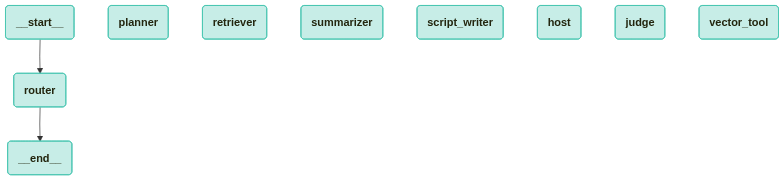

[saved] /mnt/data/podcast_graph.png
[HUMAN] 
LangGraph 학습자를 위한 팟캐스트 원고를 만들어줘. 문서에서 근거를 참고해.
----------------------------------------
[AI] 
{"route": "script_writer"}
----------------------------------------
Quality: None


In [30]:
# 데모
DEMO="LangGraph 학습자를 위한 팟캐스트 원고를 만들어줘. 문서에서 근거를 참고해."
app=compile_and_viz(build_hier_podcast_graph, visualize=True, filename="/mnt/data/podcast_graph.png")
st=run_graph(app, DEMO, thread_id="podcast-demo")
print_dialog(st)
print("Quality:", st.get("quality"))